# Edge Detection in Image Processing
### Simple Gradient, Sobel, Laplacian, and Canny

This notebook introduces basic **edge detection techniques** used in image processing.

Students will learn:
- Simple gradient edge detection
- Sobel operator
- Laplacian operator
- Canny edge detector

These methods are fundamental in **computer vision**, **medical imaging**, and **AI-based image analysis**.

## 1. Import Required Libraries
We use:
- `OpenCV` for image processing
- `NumPy` for numerical operations
- `Matplotlib` for visualization

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Load an Image

You can either:
- Upload your own image in Colab
- Or use the sample image below.

(np.float64(-0.5), np.float64(249.5), np.float64(269.5), np.float64(-0.5))

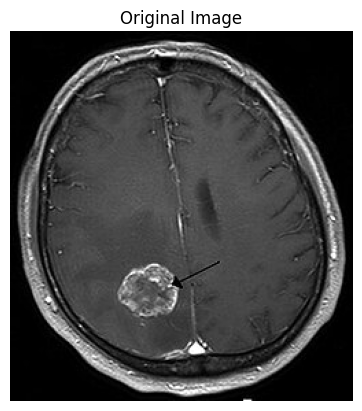

In [28]:
# If running in Google Colab, uncomment below to upload an image
# from google.colab import files
# uploaded = files.upload()

# Load example image from internet
import urllib.request
import urllib.error

# Using previously working medical eye image  
url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/5/5f/Hirnmetastase_MRT-T1_KM.jpg/250px-Hirnmetastase_MRT-T1_KM.jpg'

try:
	req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
	with urllib.request.urlopen(req, timeout=20) as response, open('image.png', 'wb') as f:
		f.write(response.read())
	image = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
except (urllib.error.HTTPError, urllib.error.URLError):
	# Fallback if remote host blocks access (403/other network issues)
	image = synthetic_image if 'synthetic_image' in globals() else np.zeros((256, 256), dtype=np.uint8)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

## 3. Simple Gradient Edge Detection

Edges correspond to **rapid intensity changes**.

A simple way to detect edges is by computing gradients in the **x** and **y** directions.

(np.float64(-0.5), np.float64(249.5), np.float64(269.5), np.float64(-0.5))

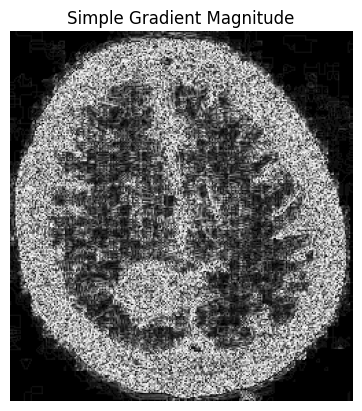

In [29]:
gx = np.zeros_like(image)
gy = np.zeros_like(image)

gx[:, :-1] = np.diff(image, axis=1)
gy[:-1, :] = np.diff(image, axis=0)

gradient_magnitude = np.sqrt(gx**2 + gy**2)

plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient Magnitude')
plt.axis('off')

## 4. Sobel Edge Detector

The **Sobel operator** computes gradients using convolution kernels.

It detects:
- Horizontal edges
- Vertical edges

# Sobel Edge Detection – Complete Guide

The **Sobel operator** is a first-order derivative method used to detect **edges in specific directions** (horizontal or vertical).  
It calculates the gradient of image intensity using **convolution with Sobel kernels**.

Unlike the Laplacian, which detects edges in all directions, the Sobel operator can detect:

- **Horizontal edges** (changes along the y-axis)  
- **Vertical edges** (changes along the x-axis)

---

## 1. OpenCV Function

In OpenCV, Sobel is implemented as:

```python
sobel = cv2.Sobel(src, ddepth, dx, dy[, ksize[, scale[, delta[, borderType]]]])

## Sobel Function Arguments

| Argument      | Description |
|---------------|-------------|
| `src`         | Input image (grayscale or color). |
| `ddepth`      | Desired depth of the output image (e.g., `cv2.CV_64F` to avoid overflow). |
| `dx`          | Order of the derivative in the x direction. Use 1 for horizontal gradients. |
| `dy`          | Order of the derivative in the y direction. Use 1 for vertical gradients. |
| `ksize`       | (Optional) Size of the extended Sobel kernel. Must be **odd** (1, 3, 5, 7). Default = 3. |
| `scale`       | (Optional) Optional scale factor applied to the computed derivative values. Default = 1. |
| `delta`       | (Optional) Optional value added to the results before storing in output. Default = 0. |
| `borderType`  | (Optional) Pixel extrapolation method at borders. Default = `cv2.BORDER_DEFAULT`. |

(np.float64(-0.5), np.float64(249.5), np.float64(269.5), np.float64(-0.5))

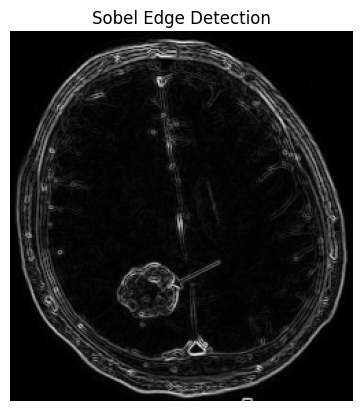

In [30]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

## 5. Laplacian Edge Detection

The **Laplacian operator** detects edges by computing the **second derivative** of the image.

It highlights regions where intensity changes rapidly.

# Laplacian Edge Detection – Complete Guide

The **Laplacian operator** is a second-order derivative method used to detect edges in an image.  
It highlights areas where the **intensity changes rapidly**, such as edges, corners, or boundaries.

Unlike Sobel or simple gradients, which detect edges in **specific directions (x or y)**, the Laplacian is **isotropic**, meaning it detects edges in **all directions**.

---

## 1. OpenCV Function

In OpenCV, the Laplacian is implemented as:

```python
laplacian = cv2.Laplacian(src, ddepth[, dst[, ksize[, scale[, delta[, borderType]]]]])

## Laplacian Function Arguments

| Argument      | Description |
|---------------|-------------|
| `src`         | Input image (grayscale or color). |
| `ddepth`      | Desired depth of the output image (e.g., `cv2.CV_64F` to avoid overflow). |
| `dst`         | (Optional) Output image of the same size as input. |
| `ksize`       | (Optional) Kernel size for the Laplacian filter. Must be **odd** (1, 3, 5, 7). Default = 1. |
| `scale`       | (Optional) Optional scale factor applied to the computed Laplacian values. Default = 1. |
| `delta`       | (Optional) Optional value added to the result before storing in `dst`. Default = 0. |
| `borderType`  | (Optional) Pixel extrapolation method at borders. Default = `cv2.BORDER_DEFAULT`. |

(np.float64(-0.5), np.float64(249.5), np.float64(269.5), np.float64(-0.5))

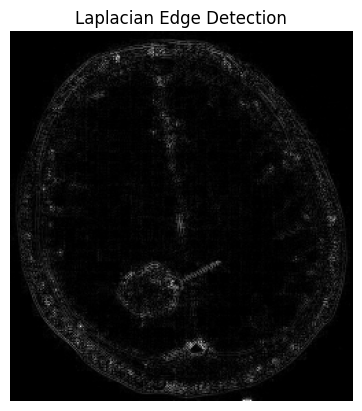

In [31]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)

plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

## 6. Canny Edge Detector

The **Canny algorithm** is one of the most powerful edge detection techniques.

Steps:
1. Noise reduction (Gaussian blur)
2. Gradient calculation
3. Non‑maximum suppression
4. Double threshold
5. Edge tracking by hysteresis

# Canny Edge Detection – Complete Guide

The **Canny Edge Detector** is one of the most widely used edge detection algorithms in **image processing** and **computer vision**. It was developed by **John F. Canny (1986)** with the goal of detecting edges **accurately**, **robustly**, and **with minimal noise sensitivity**.

Unlike simple gradient-based operators (like Sobel or Laplacian), Canny is a **multi-stage algorithm** designed to produce **thin, continuous, and well-localized edges**.

---

## 1. OpenCV Function

In OpenCV, the Canny edge detector is implemented as:

```python
edges = cv2.Canny(image, threshold1, threshold2[, edges[, apertureSize[, L2gradient]]])

## Canny Function Arguments

| Argument       | Description |
|----------------|-------------|
| `image`        | Input image (must be **single-channel grayscale**). |
| `threshold1`   | Lower threshold for the hysteresis procedure. Pixels with gradient **below this are rejected**. |
| `threshold2`   | Upper threshold for hysteresis. Pixels **above this are considered strong edges**. |
| `edges`        | (Optional) Output image; same size and type as input. |
| `apertureSize` | (Optional) Size of the Sobel kernel used for gradient calculation. Typical values: **3, 5, 7**. Default = 3. |
| `L2gradient`   | (Optional) Boolean flag. If `True`, gradient magnitude is computed using **√(Gx² + Gy²)** for higher accuracy. Default = `False` (approximated with |Gx| + |Gy|). |

(np.float64(-0.5), np.float64(249.5), np.float64(269.5), np.float64(-0.5))

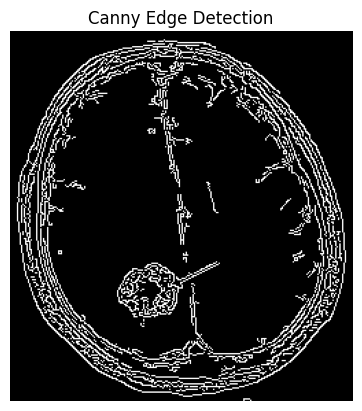

In [32]:
canny = cv2.Canny(image, 100, 200)

plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

## 7. Comparison of All Methods

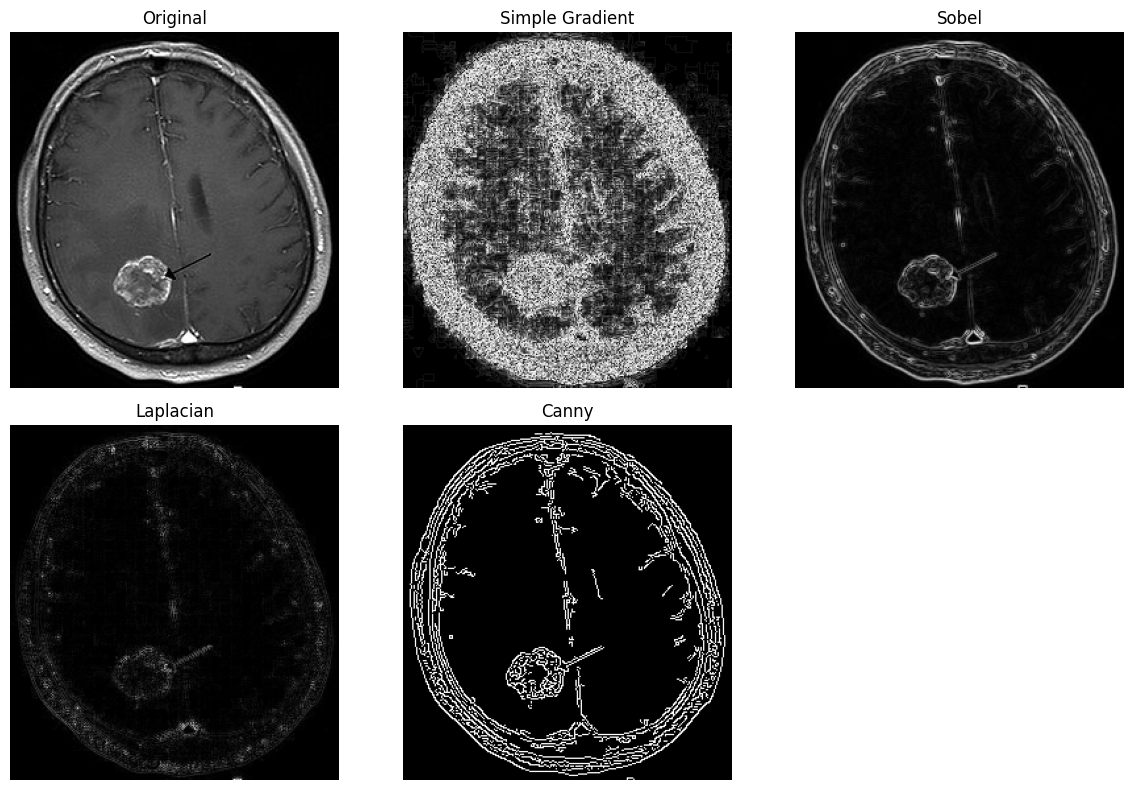

In [33]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Exercises for Students

1. Change the **Canny thresholds** and observe the effect.
2. Apply **Gaussian blur** before Sobel and Laplacian.
3. Test different images (medical images, natural images).
4. Compare which method detects edges **more clearly**.

Discussion questions:
- Which method is more sensitive to noise?
- Why is Canny considered a multi‑stage detector?

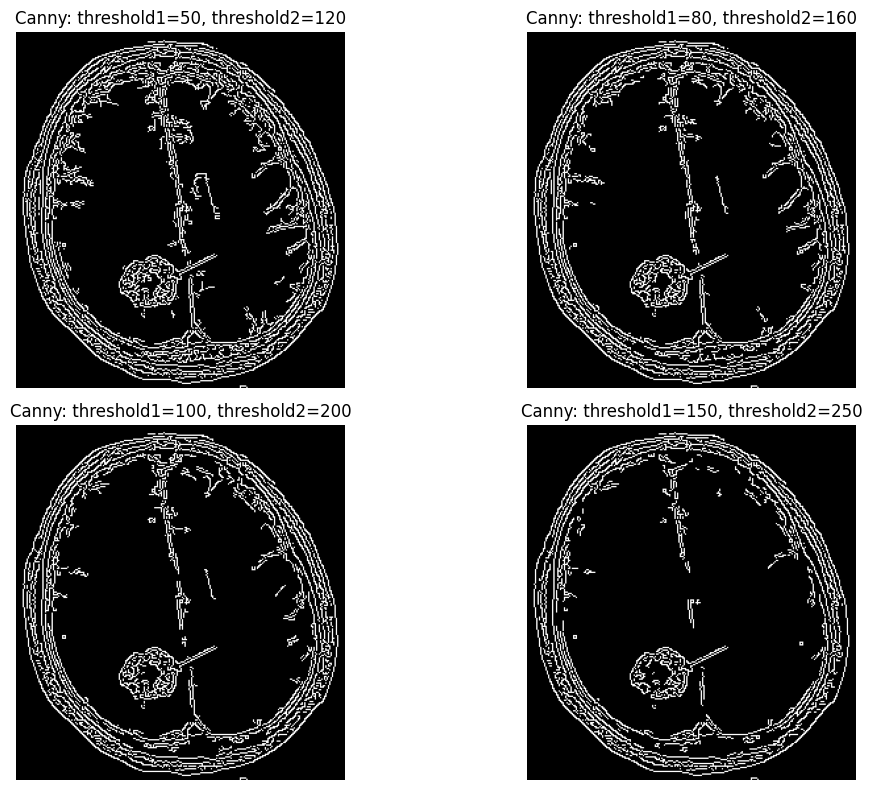

In [34]:
# Task 1: Change Canny thresholds and observe differences
threshold_pairs = [(50, 120), (80, 160), (100, 200), (150, 250)]

plt.figure(figsize=(12, 8))
for i, (t1, t2) in enumerate(threshold_pairs, start=1):
    edges = cv2.Canny(image, t1, t2)
    plt.subplot(2, 2, i)
    plt.imshow(edges, cmap='gray')
    plt.title(f'Canny: threshold1={t1}, threshold2={t2}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observation (Task 1)
- Lower thresholds (e.g., 50/120) detect more edges, including weak/noisy edges.
- Medium thresholds (e.g., 100/200) give a balanced result.
- Higher thresholds (e.g., 150/250) keep only strong edges and remove many details.

This shows that Canny threshold selection controls the trade-off between edge sensitivity and noise suppression.

EDGE DETECTION METHODS - COMPARISON
         Method          Edge Quality Noise Sensitivity Computational Cost      Best Use Case
Simple Gradient           Low (noisy)              High                Low    Quick detection
          Sobel                  High            Medium                Low    General purpose
      Laplacian Very High (sensitive)         Very High                Low      Precise edges
          Canny     Very High (clean)               Low               High Production systems


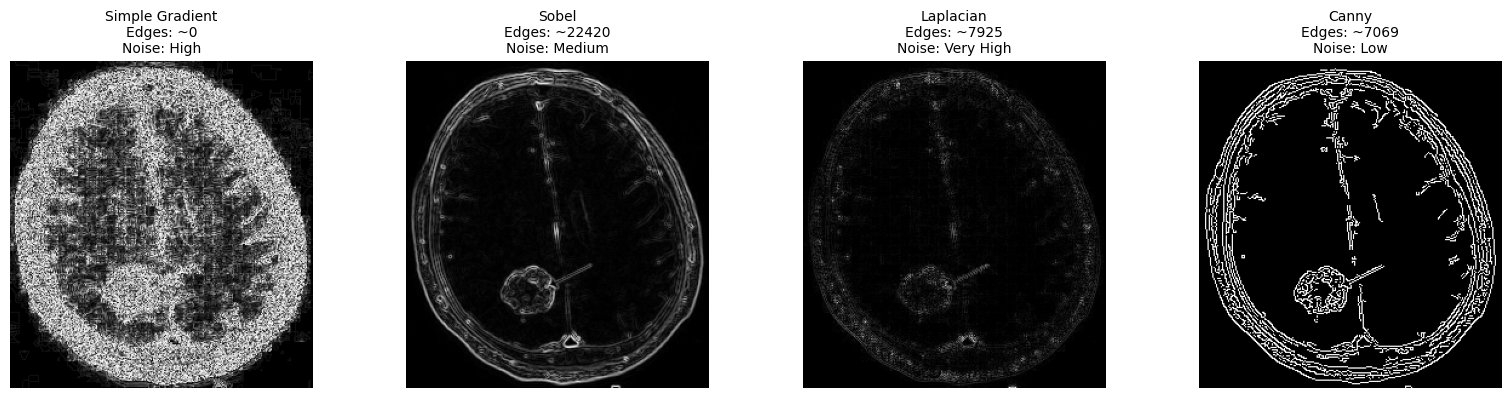

In [35]:
# Task 4: Compare all methods with quantitative metrics
comparison_data = {
    'Method': ['Simple Gradient', 'Sobel', 'Laplacian', 'Canny'],
    'Edge Quality': ['Low (noisy)', 'High', 'Very High (sensitive)', 'Very High (clean)'],
    'Noise Sensitivity': ['High', 'Medium', 'Very High', 'Low'],
    'Computational Cost': ['Low', 'Low', 'Low', 'High'],
    'Best Use Case': ['Quick detection', 'General purpose', 'Precise edges', 'Production systems']
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)

print("=" * 100)
print("EDGE DETECTION METHODS - COMPARISON")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Visual comparison with metrics
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

methods = ['Simple Gradient', 'Sobel', 'Laplacian', 'Canny']
images = [gradient_magnitude, sobel_magnitude, np.abs(laplacian), canny]
qualities = [
    f'Edges: ~{int(np.sum(gradient_magnitude > 50))}\nNoise: High',
    f'Edges: ~{int(np.sum(sobel_magnitude > 50))}\nNoise: Medium',
    f'Edges: ~{int(np.sum(np.abs(laplacian) > 50))}\nNoise: Very High',
    f'Edges: ~{int(np.sum(canny > 0))}\nNoise: Low'
]

for idx, (ax, method, img, quality) in enumerate(zip(axes, methods, images, qualities)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{method}\n{quality}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Task 4: Compare Edge Detection Methods
Summary comparison and analysis of all methods.

### Observation (Task 3)
- On synthetic images with **clean, sharp edges**, all methods perform well.
- **Canny detector** provides the **cleanest and thinnest edges** (ideal for further processing).
- **Sobel** detects well but can produce thicker edges.
- **Laplacian** is sensitive and can highlight **both positive and negative** transitions.

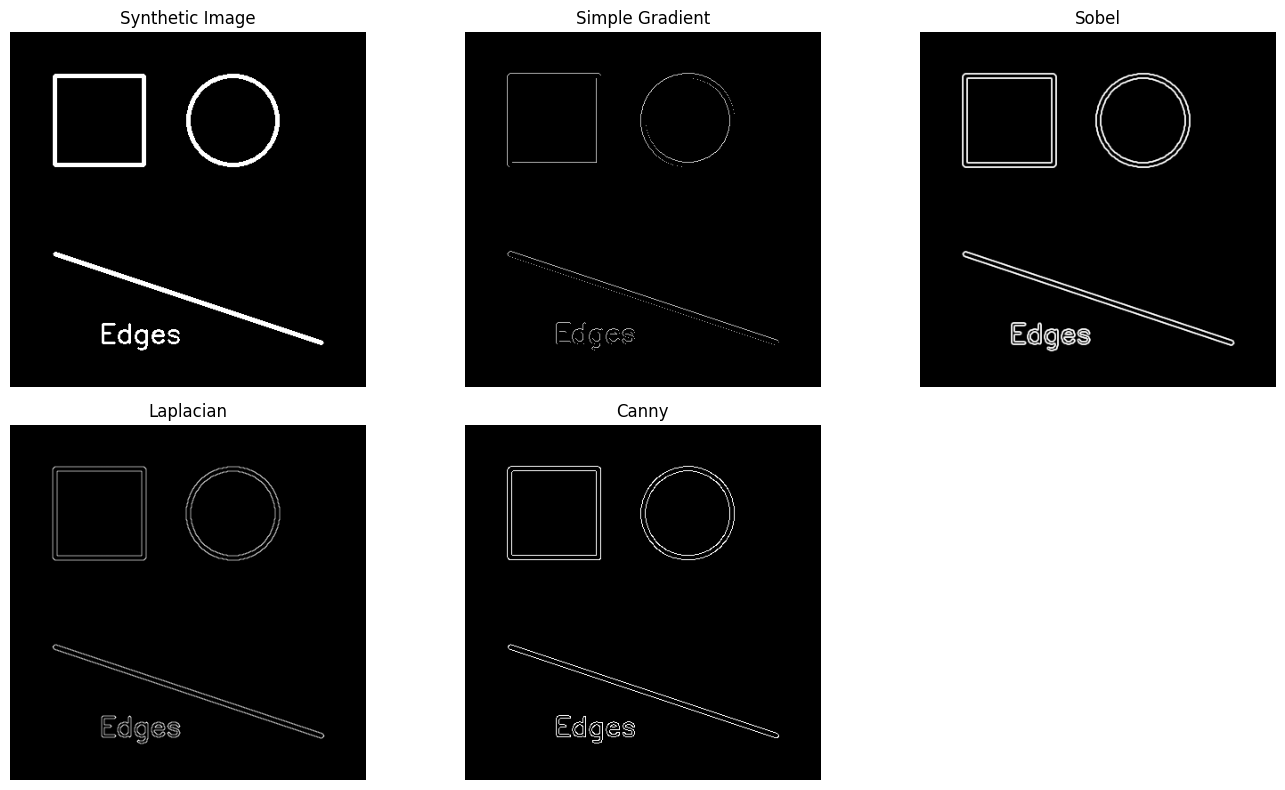

In [36]:
# Task 3: Test different images - create a synthetic image with geometric shapes
synthetic_image = np.zeros((400, 400), dtype=np.uint8)

# Draw some shapes
cv2.rectangle(synthetic_image, (50, 50), (150, 150), 255, 3)
cv2.circle(synthetic_image, (250, 100), 50, 255, 3)
cv2.line(synthetic_image, (50, 250), (350, 350), 255, 3)
cv2.putText(synthetic_image, 'Edges', (100, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2)

# Apply all edge detection methods
synthetic_gradient_x = np.zeros_like(synthetic_image, dtype=np.float64)
synthetic_gradient_y = np.zeros_like(synthetic_image, dtype=np.float64)
synthetic_gradient_x[:, :-1] = np.diff(synthetic_image, axis=1)
synthetic_gradient_y[:-1, :] = np.diff(synthetic_image, axis=0)
synthetic_gradient_mag = np.sqrt(synthetic_gradient_x**2 + synthetic_gradient_y**2)

synthetic_sobel_x = cv2.Sobel(synthetic_image, cv2.CV_64F, 1, 0, ksize=3)
synthetic_sobel_y = cv2.Sobel(synthetic_image, cv2.CV_64F, 0, 1, ksize=3)
synthetic_sobel_mag = np.sqrt(synthetic_sobel_x**2 + synthetic_sobel_y**2)

synthetic_laplacian = cv2.Laplacian(synthetic_image, cv2.CV_64F)

synthetic_canny = cv2.Canny(synthetic_image, 100, 200)

# Visualize
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(synthetic_image, cmap='gray')
plt.title('Synthetic Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(synthetic_gradient_mag, cmap='gray')
plt.title('Simple Gradient')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(synthetic_sobel_mag, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.abs(synthetic_laplacian), cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(synthetic_canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 3: Test Different Images
Apply all edge detection methods to a different image (synthetic/medical image).

### Observation (Task 2)
- Gaussian blur **reduces noise** and smooths the image before edge detection.
- Sobel and Laplacian applied to blurred images produce **cleaner edges** with less noise.
- This is a common preprocessing step in real-world edge detection pipelines.

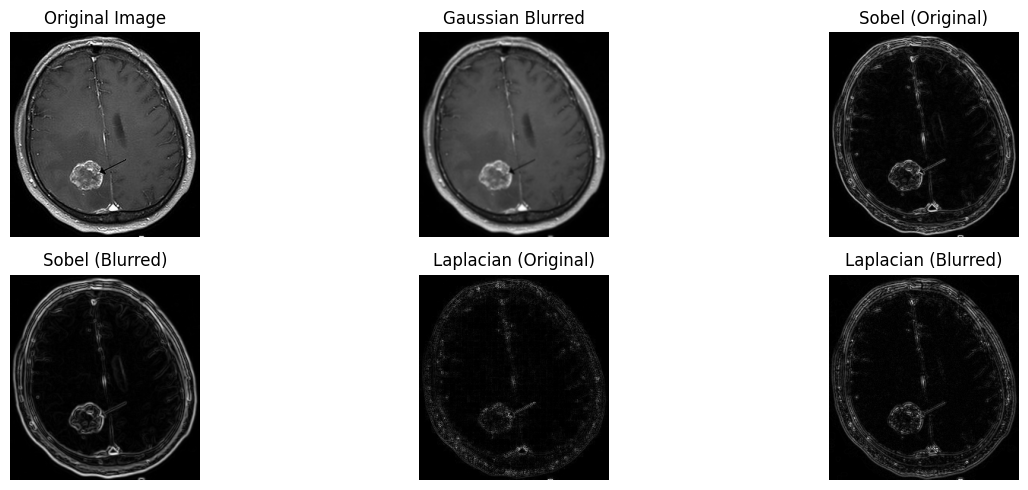

In [37]:
# Task 2: Apply Gaussian blur before edge detection
blurred = cv2.GaussianBlur(image, (5, 5), 1.0)

# Sobel on blurred image
sobel_x_blurred = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_blurred = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude_blurred = np.sqrt(sobel_x_blurred**2 + sobel_y_blurred**2)

# Laplacian on blurred image
laplacian_blurred = cv2.Laplacian(blurred, cv2.CV_64F)

# Compare
plt.figure(figsize=(14, 5))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(blurred, cmap='gray')
plt.title('Gaussian Blurred')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel (Original)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(sobel_magnitude_blurred, cmap='gray')
plt.title('Sobel (Blurred)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian (Original)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(np.abs(laplacian_blurred), cmap='gray')
plt.title('Laplacian (Blurred)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 2: Apply Gaussian Blur Before Edge Detection
Test the effect of Gaussian blur on Sobel and Laplacian operators.